## Defualt params:
`(500, 500) and (1000, 1000) network area are *NOT* tested for node placement.`
1. Initial energy= 0.5J
2. Comm range= 50m
3. Sink speed= 25m/round
4. Net area= (100, 100)
5. Nodes num= 100

## Basic Methods

In [1]:
import sys
sys.path.append(r"D:\Papers\4) Finished Articles\6. MWSN - DCHPC\DCHPC\ModelClasses")
from simulation import Simulation
from ConfigClass.config import plot_comparison, visualize_deployment

In [2]:
def plot_time_series(time_series_dict, label, title, color='b'):
    rounds_list = time_series_dict['rounds']
    values_list = time_series_dict[label]

    min_len = min(len(r) for r in rounds_list)
    
    round_grid = np.full((len(rounds_list), min_len), np.nan)
    value_grid = np.full((len(values_list), min_len), np.nan)

    for i, (rds, vals) in enumerate(zip(rounds_list, values_list)):
        round_grid[i, :] = rds[:min_len]
        value_grid[i, :] = vals[:min_len]

    avg_rounds = np.nanmean(round_grid, axis=0)  
    avg_vals = np.nanmean(value_grid, axis=0)
    std_vals = np.nanstd(value_grid, axis=0)


    valid = ~np.isnan(avg_vals)
    avg_rounds = avg_rounds[valid]
    avg_vals = avg_vals[valid]
    std_vals = std_vals[valid]

    plt.plot(avg_rounds, avg_vals, label=f'{title} (Mean)', color=color, linewidth=2)
    plt.fill_between(avg_rounds, 
                     avg_vals - std_vals, 
                     avg_vals + std_vals, 
                     color=color, alpha=0.2, label=f'{title} ± Std')

In [3]:
import numpy as np
import random


def run_multiple_simulations(area_size, n_nodes, sink_mode, routing_mode, mode, n_runs=30, CHS="optimizer", edge_threshold=0.4, tune_edge_iterations=20):
    FND, HND, LND, PDR = [], [], [], []
    TotalGenerated, TotalDelivered = [], []
    Avg_E2E_Delay_Rounds, Avg_E2E_Delay_Sec = [], []
    EC, avg_RE, TH, TH_pps, PLR, LB, FI, CE, Buffer_Overflow_Rate = [
    ], [], [], [], [], [], [], [], []
    CA, RL, EE, EE_Js, routing_Overhead_Bytes, Traffic_Load_Pct, Overhead_Normalized = [
    ], [], [], [], [], [], []
    round_runs, EC_runs, avg_RE_runs = [], [], []
    TH_runs, TH_pps_runs, PLR_runs, LB_runs = [], [], [], []
    FI_runs, CE_runs, Buffer_Overflow_Rate_runs = [], [], []
    CA_runs, RL_runs, EE_runs, EE_Js_runs = [], [], [], []
    routing_Overhead_Bytes_runs, Traffic_Load_Pct_runs, Overhead_Normalized_runs = [], [], []
    for seed in range(n_runs):
        np.random.seed(seed)
        random.seed(seed)
        sim = Simulation(
            area_size=area_size,
            n_nodes=n_nodes,
            rounds=60000,
            init_energy=0.5,
            comm_range=50.0,
            sink_mode=sink_mode,
            routing_mode=routing_mode,
            seed=seed,
            localization_mode=mode,
            head_selection_strategy=CHS,
            edge_threshold=edge_threshold,
            tune_edge_iterations=tune_edge_iterations
        )
        metrics, detailed_metrics = sim.run()

        rounds = np.array(detailed_metrics['round'])
        EC_vals = np.array(detailed_metrics['EC'])
        avg_RE = np.array(detailed_metrics['avg_RE'])
        TH = np.array(detailed_metrics['TH'])
        TH_pps = np.array(detailed_metrics['TH_pps'])
        PLR = np.array(detailed_metrics['PLR'])
        LB = np.array(detailed_metrics['LB'])
        FI = np.array(detailed_metrics['FI'])
        CE = np.array(detailed_metrics['CE'])
        Buffer_Overflow_Rate = np.array(
            detailed_metrics['Buffer_Overflow_Rate'])
        CA = np.array(detailed_metrics['CA'])
        RL = np.array(detailed_metrics['RL'])
        EE = np.array(detailed_metrics['EE'])
        EE_Js = np.array(detailed_metrics['EE_Js'])
        routing_Overhead_Bytes = np.array(
            detailed_metrics['Routing_Overhead_Bytes'])
        Traffic_Load_Pct = np.array(detailed_metrics['Traffic_Load_Pct'])
        Overhead_Normalized = np.array(detailed_metrics['Overhead_Normalized'])

        round_runs.append(rounds)
        EC_runs.append(EC_vals)
        avg_RE_runs.append(avg_RE)
        TH_runs.append(TH)
        TH_pps_runs.append(TH_pps)
        PLR_runs.append(PLR)
        LB_runs.append(LB)
        FI_runs.append(FI)
        CE_runs.append(CE)
        Buffer_Overflow_Rate_runs.append(
            Buffer_Overflow_Rate)
        CA_runs.append(CA)
        RL_runs.append(RL)
        EE_runs.append(EE)
        EE_Js_runs.append(EE_Js)
        routing_Overhead_Bytes_runs.append(
            routing_Overhead_Bytes)
        Traffic_Load_Pct_runs.append(Traffic_Load_Pct)
        Overhead_Normalized_runs.append(Overhead_Normalized)

        plot_res = {
            'rounds': round_runs,
            'EC': EC_runs,
            'avg_RE': avg_RE_runs,
            'TH': TH_runs,
            'TH_pps': TH_pps_runs,
            'PLR': PLR_runs,
            'LB': LB_runs,
            'FI': FI_runs,
            'CE': CE_runs,
            'Buffer_Overflow_Rate': Buffer_Overflow_Rate_runs,
            'CA': CA_runs,
            'RL': RL_runs,
            'EE': EE_runs,
            'EE_Js': EE_Js_runs,
            'routing_Overhead_Bytes': routing_Overhead_Bytes_runs,
            'Traffic_Load_Pct': Traffic_Load_Pct_runs,
            'Overhead_Normalized': Overhead_Normalized_runs

        }

        FND.append(metrics['FND'])
        HND.append(metrics['HND'])
        LND.append(metrics['LND'])
        PDR.append(metrics['PDR'])
        TotalGenerated.append(metrics['TotalGenerated'])
        TotalDelivered.append(metrics['TotalDelivered'])
        Avg_E2E_Delay_Rounds.append(metrics['Avg_E2E_Delay_Rounds'])
        Avg_E2E_Delay_Sec.append(metrics['Avg_E2E_Delay_Sec'])

    print("\n")

    return [np.array(FND), np.array(HND), np.array(LND),
            np.array(PDR), np.array(TotalGenerated), np.array(TotalDelivered),
            np.array(Avg_E2E_Delay_Rounds), np.array(Avg_E2E_Delay_Sec)], plot_res

## Random Node Deployment vs. Voronoi-RL 

### (100, 100) area size, 100 nodes

In [4]:
# Run both methods
drl_lifetimes, plot_drl = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="DRL", n_runs=30, tune_edge_iterations=50)
baseline_lifetimes, plot_base = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="random", n_runs=30)


print(
    f"Mean DRL FND: {drl_lifetimes[0].mean():.2f} ± {drl_lifetimes[0].std():.2f}")
print(
    f"Mean DRL HND: {drl_lifetimes[1].mean():.2f} ± {drl_lifetimes[1].std():.2f}")
print(
    f"Mean DRL LND: {drl_lifetimes[2].mean():.2f} ± {drl_lifetimes[2].std():.2f}")
print(
    f"Mean DRL PDR: {drl_lifetimes[3].mean():.2f} ± {drl_lifetimes[3].std():.2f}")
print(
    f"Mean DRL TotalGenerated: {drl_lifetimes[4].mean():.2f} ± {drl_lifetimes[4].std():.2f}")
print(
    f"Mean DRL TotalDelivered: {drl_lifetimes[5].mean():.2f} ± {drl_lifetimes[5].std():.2f}")
print(
    f"Mean DRL Avg_E2E_Delay_Rounds: {drl_lifetimes[6].mean():.2f} ± {drl_lifetimes[6].std():.2f}")
print(
    f"Mean DRL Avg_E2E_Delay_Sec: {drl_lifetimes[7].mean():.2f} ± {drl_lifetimes[7].std():.2f}")



print("\n\n\n")
print(
    f"Mean Baseline FND: {baseline_lifetimes[0].mean():.2f} ± {baseline_lifetimes[0].std():.2f}")
print(
    f"Mean Baseline HND: {baseline_lifetimes[1].mean():.2f} ± {baseline_lifetimes[1].std():.2f}")
print(
    f"Mean Baseline LND: {baseline_lifetimes[2].mean():.2f} ± {baseline_lifetimes[2].std():.2f}")
print(
    f"Mean Baseline PDR: {baseline_lifetimes[3].mean():.2f} ± {baseline_lifetimes[3].std():.2f}")
print(
    f"Mean Baseline TotalGenerated: {baseline_lifetimes[4].mean():.2f} ± {baseline_lifetimes[4].std():.2f}")
print(
    f"Mean Baseline TotalDelivered: {baseline_lifetimes[5].mean():.2f} ± {baseline_lifetimes[5].std():.2f}")
print(
    f"Mean Baseline Avg_E2E_Delay_Rounds: {baseline_lifetimes[6].mean():.2f} ± {baseline_lifetimes[6].std():.2f}")
print(
    f"Mean Baseline Avg_E2E_Delay_Sec: {baseline_lifetimes[7].mean():.2f} ± {baseline_lifetimes[7].std():.2f}")

[3, 4, 7, 8, 9, 10, 13, 17, 19, 23, 26, 27, 30, 33, 34, 37, 38, 41, 44, 46, 48, 49, 51, 54, 59, 61, 63, 66, 71, 73, 74, 75, 77, 79, 82, 83, 85, 86, 88, 89, 96]
[RL-Corrected] Optimizing 41 edge nodes using Q-Learning...
  Iter 0: Epsilon=0.85, Global Reward=0.9518
  Iter 5: Epsilon=0.66, Global Reward=0.9520
  Iter 10: Epsilon=0.51, Global Reward=0.9519
  Iter 15: Epsilon=0.40, Global Reward=0.9522
  Iter 20: Epsilon=0.31, Global Reward=0.9520
  Iter 25: Epsilon=0.24, Global Reward=0.9521
  Iter 30: Epsilon=0.18, Global Reward=0.9520
  Iter 35: Epsilon=0.14, Global Reward=0.9519
  Iter 40: Epsilon=0.11, Global Reward=0.9518
  Iter 45: Epsilon=0.09, Global Reward=0.9517
[Info] Sink speed: 25.0 m/round = 0.50 m/s
[1, 2, 6, 10, 12, 13, 14, 16, 19, 20, 23, 25, 27, 28, 34, 35, 38, 43, 45, 48, 51, 52, 53, 54, 55, 56, 58, 59, 60, 61, 65, 66, 67, 69, 70, 71, 72, 74, 75, 79, 82, 85, 91, 95, 97, 98]
[RL-Corrected] Optimizing 46 edge nodes using Q-Learning...
  Iter 0: Epsilon=0.85, Global Reward

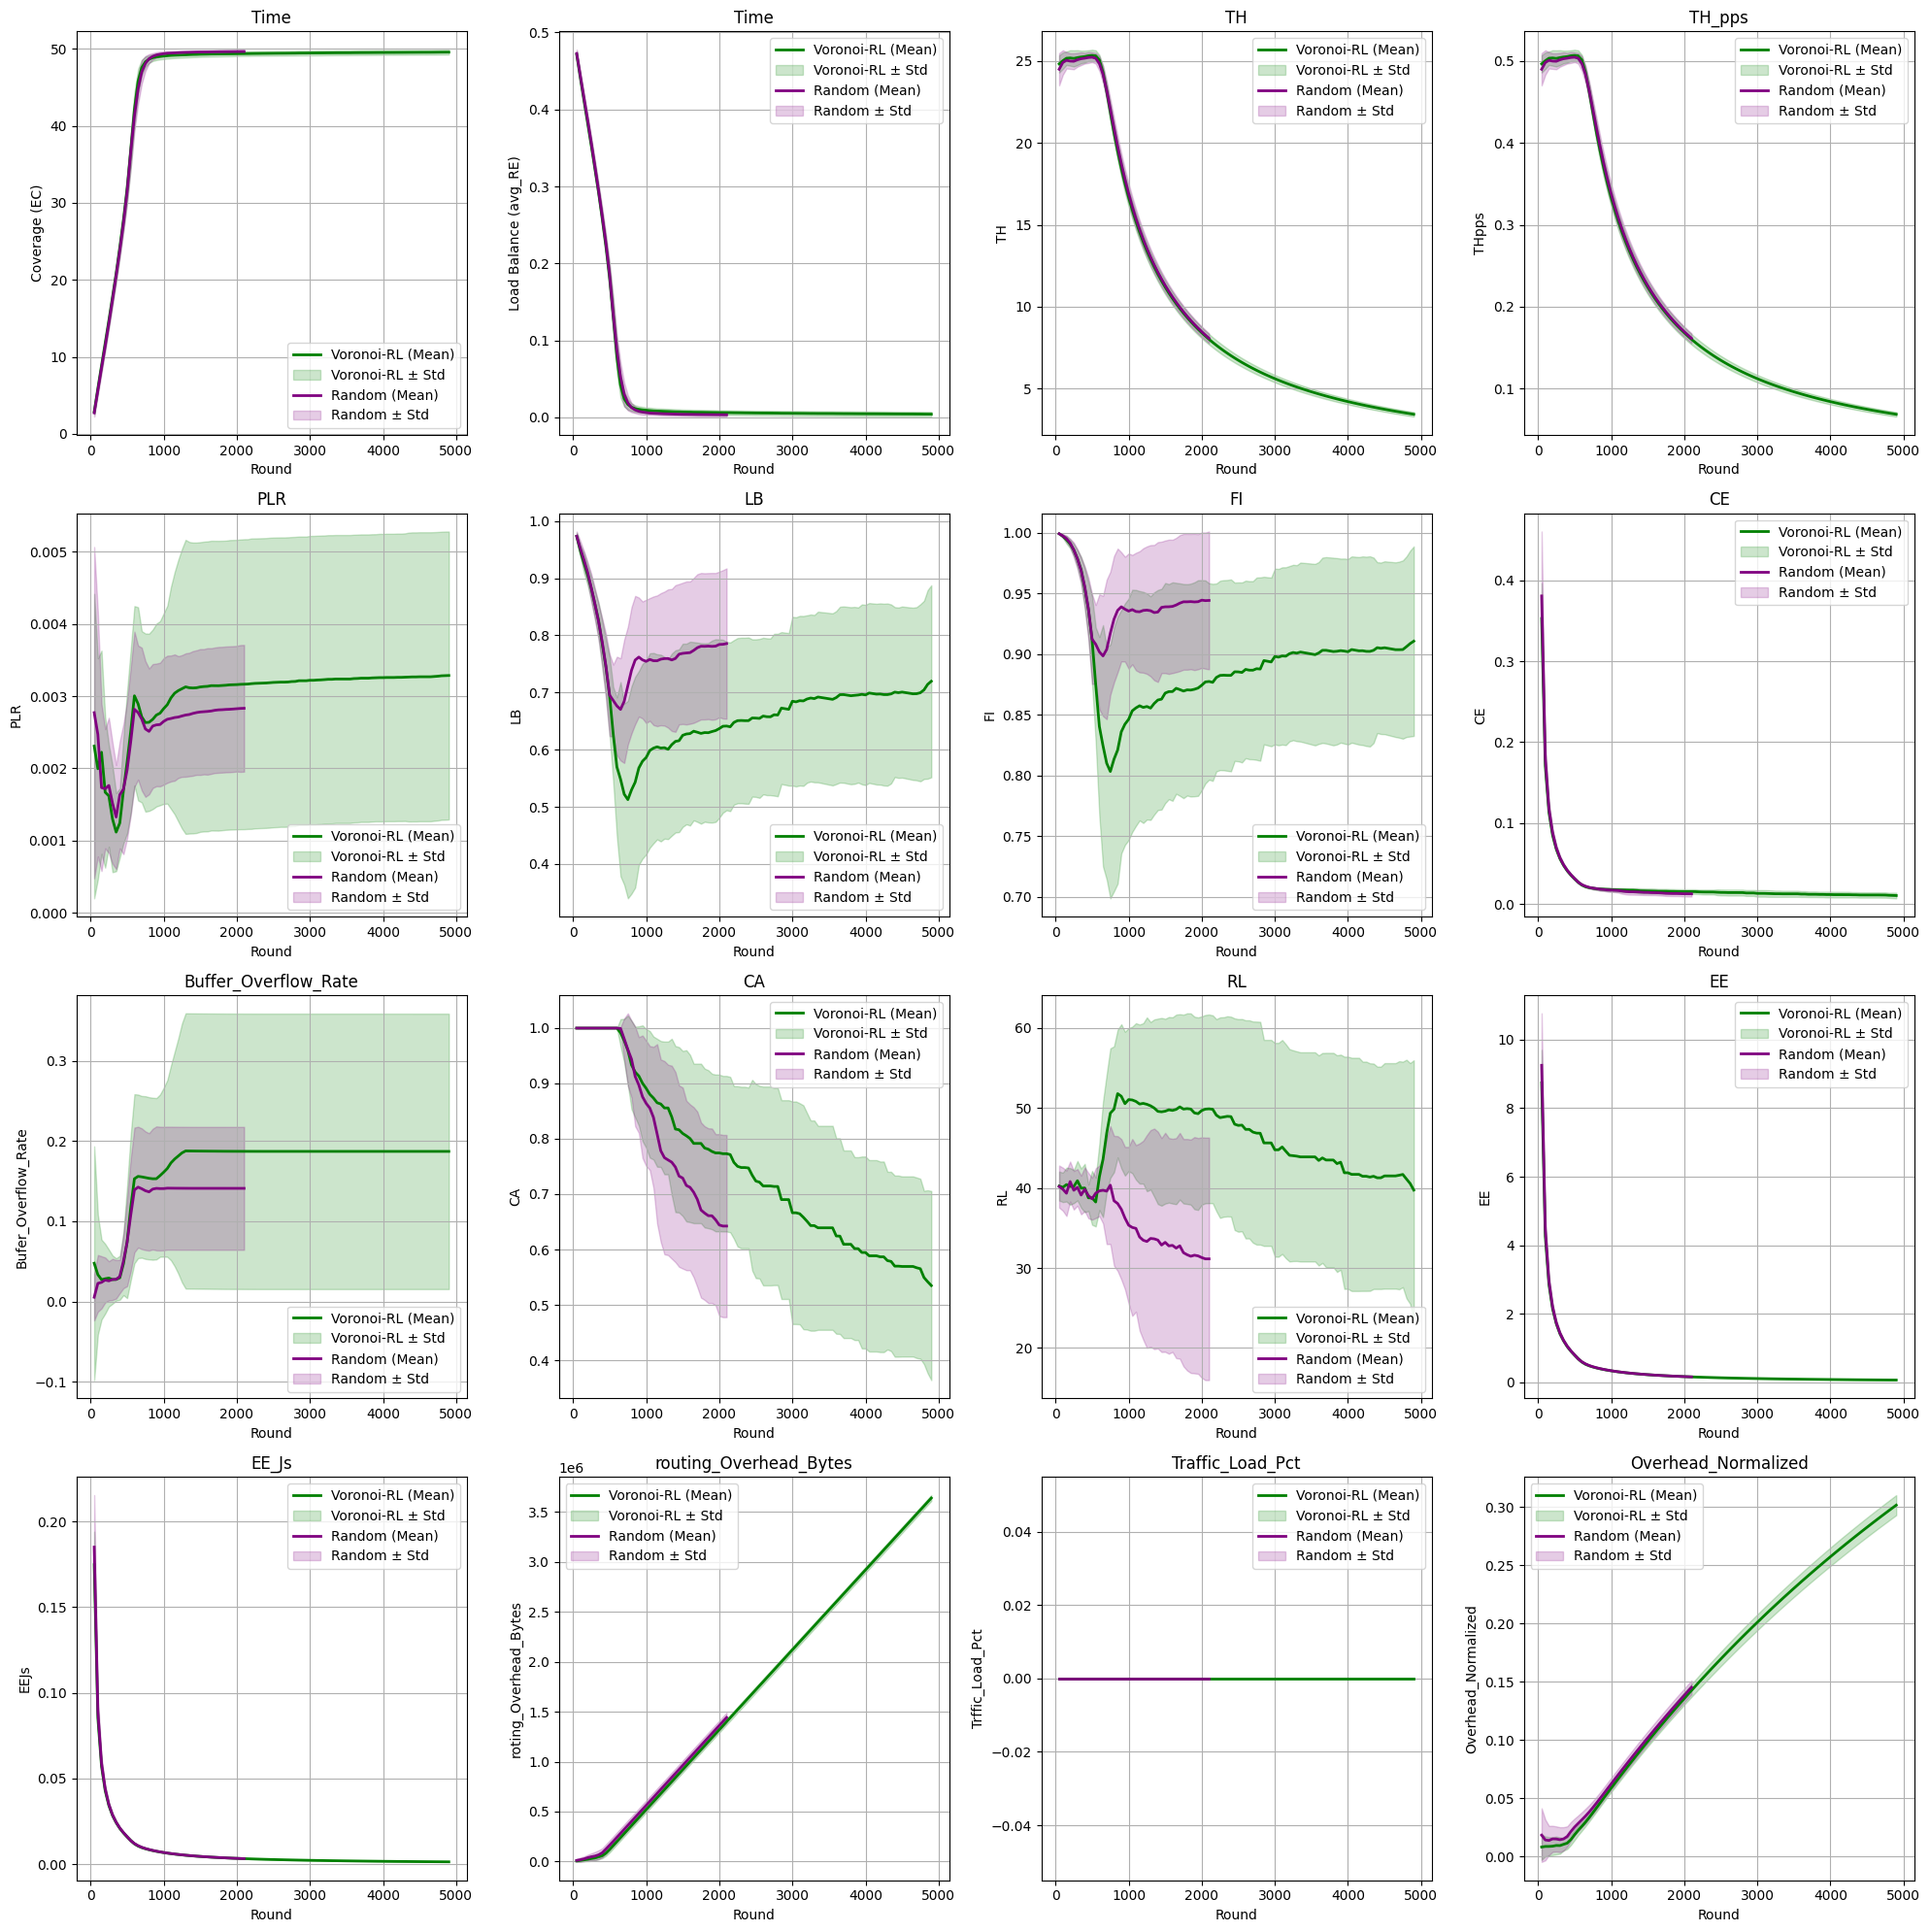

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))

# EC
plt.subplot(4, 4, 1)
plot_time_series(plot_drl, 'EC', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'EC', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Coverage (EC)')
plt.title('Time')
plt.grid(True)
plt.legend()

# avg_RE
plt.subplot(4, 4, 2)
plot_time_series(plot_drl, 'avg_RE', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'avg_RE', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Load Balance (avg_RE)')
plt.title('Time')
plt.grid(True)
plt.legend()

# TH
plt.subplot(4, 4, 3)
plot_time_series(plot_drl, 'TH', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'TH', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('TH')
plt.title('TH')
plt.grid(True)
plt.legend()

# TH_pps
plt.subplot(4, 4, 4)
plot_time_series(plot_drl, 'TH_pps', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'TH_pps', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('THpps')
plt.title('TH_pps')
plt.grid(True)
plt.legend()

# PLR
plt.subplot(4, 4, 5)
plot_time_series(plot_drl, 'PLR', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'PLR', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('PLR')
plt.title('PLR')
plt.grid(True)
plt.legend()

# LB
plt.subplot(4, 4, 6)
plot_time_series(plot_drl, 'LB', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'LB', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('LB')
plt.title('LB')
plt.grid(True)
plt.legend()

# FI
plt.subplot(4, 4, 7)
plot_time_series(plot_drl, 'FI', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'FI', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('FI')
plt.title('FI')
plt.grid(True)
plt.legend()

# CE
plt.subplot(4, 4, 8)
plot_time_series(plot_drl, 'CE', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'CE', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('CE')
plt.title('CE')
plt.grid(True)
plt.legend()

# Buffer_Overflow_Rate
plt.subplot(4, 4, 9)
plot_time_series(plot_drl, 'Buffer_Overflow_Rate', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'Buffer_Overflow_Rate', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Bufer_Overflow_Rate')
plt.title('Buffer_Overflow_Rate')
plt.grid(True)
plt.legend()

# CA
plt.subplot(4, 4, 10)
plot_time_series(plot_drl, 'CA', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'CA', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('CA')
plt.title('CA')
plt.grid(True)
plt.legend()

# RL
plt.subplot(4, 4, 11)
plot_time_series(plot_drl, 'RL', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'RL', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('RL')
plt.title('RL')
plt.grid(True)
plt.legend()

# EE
plt.subplot(4, 4, 12)
plot_time_series(plot_drl, 'EE', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'EE', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('EE')
plt.title('EE')
plt.grid(True)
plt.legend()

# EE_Js
plt.subplot(4, 4, 13)
plot_time_series(plot_drl, 'EE_Js', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'EE_Js', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('EEJs')
plt.title('EE_Js')
plt.grid(True)
plt.legend()

# routing_Overhead_Bytes
plt.subplot(4, 4, 14)
plot_time_series(plot_drl, 'routing_Overhead_Bytes',
                 "Voronoi-RL", color='green')
plot_time_series(plot_base, 'routing_Overhead_Bytes', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('roting_Overhead_Bytes')
plt.title('routing_Overhead_Bytes')
plt.grid(True)
plt.legend()

# Traffic_Load_Pct
plt.subplot(4, 4, 15)
plot_time_series(plot_drl, 'Traffic_Load_Pct', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'Traffic_Load_Pct', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Trffic_Load_Pct')
plt.title('Traffic_Load_Pct')
plt.grid(True)
plt.legend()

# Overhead_Normalized
plt.subplot(4, 4, 16)
plot_time_series(plot_drl, 'Overhead_Normalized', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'Overhead_Normalized', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Overhead_Normalized')
plt.title('Overhead_Normalized')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('metrics_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

### (200, 200) area size, 100 nodes

In [ ]:
# Run both methods
drl_lifetimes, plot_drl = run_multiple_simulations(area_size=(
    200, 200), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="DRL", n_runs=30)
baseline_lifetimes, plot_base = run_multiple_simulations(area_size=(
    200, 200), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="random", n_runs=30)


print(
    f"Mean DRL FND: {drl_lifetimes[0].mean():.2f} ± {drl_lifetimes[0].std():.2f}")
print(
    f"Mean DRL HND: {drl_lifetimes[1].mean():.2f} ± {drl_lifetimes[1].std():.2f}")
print(
    f"Mean DRL LND: {drl_lifetimes[2].mean():.2f} ± {drl_lifetimes[2].std():.2f}")
print(
    f"Mean DRL PDR: {drl_lifetimes[3].mean():.2f} ± {drl_lifetimes[3].std():.2f}")
print(
    f"Mean DRL TotalGenerated: {drl_lifetimes[4].mean():.2f} ± {drl_lifetimes[4].std():.2f}")
print(
    f"Mean DRL TotalDelivered: {drl_lifetimes[5].mean():.2f} ± {drl_lifetimes[5].std():.2f}")
print(
    f"Mean DRL Avg_E2E_Delay_Rounds: {drl_lifetimes[6].mean():.2f} ± {drl_lifetimes[6].std():.2f}")
print(
    f"Mean DRL Avg_E2E_Delay_Sec: {drl_lifetimes[7].mean():.2f} ± {drl_lifetimes[7].std():.2f}")


print("\n\n\n")
print(
    f"Mean Baseline FND: {baseline_lifetimes[0].mean():.2f} ± {baseline_lifetimes[0].std():.2f}")
print(
    f"Mean Baseline HND: {baseline_lifetimes[1].mean():.2f} ± {baseline_lifetimes[1].std():.2f}")
print(
    f"Mean Baseline LND: {baseline_lifetimes[2].mean():.2f} ± {baseline_lifetimes[2].std():.2f}")
print(
    f"Mean Baseline PDR: {baseline_lifetimes[3].mean():.2f} ± {baseline_lifetimes[3].std():.2f}")
print(
    f"Mean Baseline TotalGenerated: {baseline_lifetimes[4].mean():.2f} ± {baseline_lifetimes[4].std():.2f}")
print(
    f"Mean Baseline TotalDelivered: {baseline_lifetimes[5].mean():.2f} ± {baseline_lifetimes[5].std():.2f}")
print(
    f"Mean Baseline Avg_E2E_Delay_Rounds: {baseline_lifetimes[6].mean():.2f} ± {baseline_lifetimes[6].std():.2f}")
print(
    f"Mean Baseline Avg_E2E_Delay_Sec: {baseline_lifetimes[7].mean():.2f} ± {baseline_lifetimes[7].std():.2f}")

In [ ]:
plt.figure(figsize=(15, 5))

# CA
plt.subplot(1, 3, 1)
plot_time_series(plot_drl, 'CA', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'CA', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Coverage (CA)')
plt.title('Spatial Coverage over Time')
plt.grid(True)
plt.legend()

# LB
plt.subplot(1, 3, 2)
plot_time_series(plot_drl, 'LB', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'LB', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Load Balance (LB)')
plt.title('Load Balance over Time')
plt.grid(True)
plt.legend()

# CE
plt.subplot(1, 3, 3)
plot_time_series(plot_drl, 'EC', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'EC', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Coverage Efficiency (EC)')
plt.title('Coverage per Energy Unit (EC)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('metrics_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

### (500, 500) area size, 100 nodes

In [ ]:
# Run both methods
drl_lifetimes, plot_drl = run_multiple_simulations(area_size=(
    500, 500), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="DRL", n_runs=30, edge_threshold=0.01, tune_edge_iterations=10)
baseline_lifetimes, plot_base = run_multiple_simulations(area_size=(
    500, 500), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="random", n_runs=30)


print(
    f"Mean DRL FND: {drl_lifetimes[0].mean():.2f} ± {drl_lifetimes[0].std():.2f}")
print(
    f"Mean DRL HND: {drl_lifetimes[1].mean():.2f} ± {drl_lifetimes[1].std():.2f}")
print(
    f"Mean DRL LND: {drl_lifetimes[2].mean():.2f} ± {drl_lifetimes[2].std():.2f}")
print(
    f"Mean DRL PDR: {drl_lifetimes[3].mean():.2f} ± {drl_lifetimes[3].std():.2f}")
print(
    f"Mean DRL TotalGenerated: {drl_lifetimes[4].mean():.2f} ± {drl_lifetimes[4].std():.2f}")
print(
    f"Mean DRL TotalDelivered: {drl_lifetimes[5].mean():.2f} ± {drl_lifetimes[5].std():.2f}")
print(
    f"Mean DRL Avg_E2E_Delay_Rounds: {drl_lifetimes[6].mean():.2f} ± {drl_lifetimes[6].std():.2f}")
print(
    f"Mean DRL Avg_E2E_Delay_Sec: {drl_lifetimes[7].mean():.2f} ± {drl_lifetimes[7].std():.2f}")


print("\n\n\n")
print(
    f"Mean Baseline FND: {baseline_lifetimes[0].mean():.2f} ± {baseline_lifetimes[0].std():.2f}")
print(
    f"Mean Baseline HND: {baseline_lifetimes[1].mean():.2f} ± {baseline_lifetimes[1].std():.2f}")
print(
    f"Mean Baseline LND: {baseline_lifetimes[2].mean():.2f} ± {baseline_lifetimes[2].std():.2f}")
print(
    f"Mean Baseline PDR: {baseline_lifetimes[3].mean():.2f} ± {baseline_lifetimes[3].std():.2f}")
print(
    f"Mean Baseline TotalGenerated: {baseline_lifetimes[4].mean():.2f} ± {baseline_lifetimes[4].std():.2f}")
print(
    f"Mean Baseline TotalDelivered: {baseline_lifetimes[5].mean():.2f} ± {baseline_lifetimes[5].std():.2f}")
print(
    f"Mean Baseline Avg_E2E_Delay_Rounds: {baseline_lifetimes[6].mean():.2f} ± {baseline_lifetimes[6].std():.2f}")
print(
    f"Mean Baseline Avg_E2E_Delay_Sec: {baseline_lifetimes[7].mean():.2f} ± {baseline_lifetimes[7].std():.2f}")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# CA
plt.subplot(1, 3, 1)
plot_time_series(plot_drl, 'CA', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'CA', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Coverage (CA)')
plt.title('Spatial Coverage over Time')
plt.grid(True)
plt.legend()

# LB
plt.subplot(1, 3, 2)
plot_time_series(plot_drl, 'LB', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'LB', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Load Balance (LB)')
plt.title('Load Balance over Time')
plt.grid(True)
plt.legend()

# CE
plt.subplot(1, 3, 3)
plot_time_series(plot_drl, 'EC', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'EC', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Coverage Efficiency (EC)')
plt.title('Coverage per Energy Unit (EC)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('metrics_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

### (1000, 1000) area size, 100 nodes

In [ ]:
# Run both methods
drl_lifetimes, plot_drl = run_multiple_simulations(area_size=(
    1000, 1000), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="DRL", n_runs=30, edge_threshold=0.01, tune_edge_iterations=10)
baseline_lifetimes, plot_base = run_multiple_simulations(area_size=(
    1000, 1000), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="random", n_runs=30)


print(
    f"Mean DRL FND: {drl_lifetimes[0].mean():.2f} ± {drl_lifetimes[0].std():.2f}")
print(
    f"Mean DRL HND: {drl_lifetimes[1].mean():.2f} ± {drl_lifetimes[1].std():.2f}")
print(
    f"Mean DRL LND: {drl_lifetimes[2].mean():.2f} ± {drl_lifetimes[2].std():.2f}")
print(
    f"Mean DRL PDR: {drl_lifetimes[3].mean():.2f} ± {drl_lifetimes[3].std():.2f}")
print(
    f"Mean DRL TotalGenerated: {drl_lifetimes[4].mean():.2f} ± {drl_lifetimes[4].std():.2f}")
print(
    f"Mean DRL TotalDelivered: {drl_lifetimes[5].mean():.2f} ± {drl_lifetimes[5].std():.2f}")
print(
    f"Mean DRL Avg_E2E_Delay_Rounds: {drl_lifetimes[6].mean():.2f} ± {drl_lifetimes[6].std():.2f}")
print(
    f"Mean DRL Avg_E2E_Delay_Sec: {drl_lifetimes[7].mean():.2f} ± {drl_lifetimes[7].std():.2f}")


print("\n\n\n")
print(
    f"Mean Baseline FND: {baseline_lifetimes[0].mean():.2f} ± {baseline_lifetimes[0].std():.2f}")
print(
    f"Mean Baseline HND: {baseline_lifetimes[1].mean():.2f} ± {baseline_lifetimes[1].std():.2f}")
print(
    f"Mean Baseline LND: {baseline_lifetimes[2].mean():.2f} ± {baseline_lifetimes[2].std():.2f}")
print(
    f"Mean Baseline PDR: {baseline_lifetimes[3].mean():.2f} ± {baseline_lifetimes[3].std():.2f}")
print(
    f"Mean Baseline TotalGenerated: {baseline_lifetimes[4].mean():.2f} ± {baseline_lifetimes[4].std():.2f}")
print(
    f"Mean Baseline TotalDelivered: {baseline_lifetimes[5].mean():.2f} ± {baseline_lifetimes[5].std():.2f}")
print(
    f"Mean Baseline Avg_E2E_Delay_Rounds: {baseline_lifetimes[6].mean():.2f} ± {baseline_lifetimes[6].std():.2f}")
print(
    f"Mean Baseline Avg_E2E_Delay_Sec: {baseline_lifetimes[7].mean():.2f} ± {baseline_lifetimes[7].std():.2f}")

In [ ]:
plt.figure(figsize=(15, 5))

# CA
plt.subplot(1, 3, 1)
plot_time_series(plot_drl, 'CA', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'CA', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Coverage (CA)')
plt.title('Spatial Coverage over Time')
plt.grid(True)
plt.legend()

# LB
plt.subplot(1, 3, 2)
plot_time_series(plot_drl, 'LB', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'LB', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Load Balance (LB)')
plt.title('Load Balance over Time')
plt.grid(True)
plt.legend()

# CE
plt.subplot(1, 3, 3)
plot_time_series(plot_drl, 'EC', "Voronoi-RL", color='green')
plot_time_series(plot_base, 'EC', "Random", color='purple')
plt.xlabel('Round')
plt.ylabel('Coverage Efficiency (EC)')
plt.title('Coverage per Energy Unit (EC)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('metrics_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Different MS patterns

In [ ]:
# Run both methods
eeosp_lifetimes, plot_eeosp = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="random", n_runs=30)
adaptive_lifetimes, plot_adaptive = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="adaptive", routing_mode="multi-hop", mode="random", n_runs=30)
fixed_lifetimes, plot_fixed = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="fixed", routing_mode="multi-hop", mode="random", n_runs=30)
random_lifetimes, plot_random = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="random", routing_mode="multi-hop", mode="random", n_runs=30)

print(
    f"Mean eeosp FND: {eeosp_lifetimes[0].mean():.2f} ± {eeosp_lifetimes[0].std():.2f}")
print(
    f"Mean eeosp HND: {eeosp_lifetimes[1].mean():.2f} ± {eeosp_lifetimes[1].std():.2f}")
print(
    f"Mean eeosp LND: {eeosp_lifetimes[2].mean():.2f} ± {eeosp_lifetimes[2].std():.2f}")
print(
    f"Mean eeosp PDR: {eeosp_lifetimes[3].mean():.2f} ± {eeosp_lifetimes[3].std():.2f}")
print(
    f"Mean eeosp TotalGenerated: {eeosp_lifetimes[4].mean():.2f} ± {eeosp_lifetimes[4].std():.2f}")
print(
    f"Mean eeosp TotalDelivered: {eeosp_lifetimes[5].mean():.2f} ± {eeosp_lifetimes[5].std():.2f}")
print(
    f"Mean eeosp Avg_E2E_Delay_Rounds: {eeosp_lifetimes[6].mean():.2f} ± {eeosp_lifetimes[6].std():.2f}")
print(
    f"Mean eeosp Avg_E2E_Delay_Sec: {eeosp_lifetimes[7].mean():.2f} ± {eeosp_lifetimes[7].std():.2f}")


print("\n\n")
print(
    f"Mean adaptive FND: {adaptive_lifetimes[0].mean():.2f} ± {adaptive_lifetimes[0].std():.2f}")
print(
    f"Mean adaptive HND: {adaptive_lifetimes[1].mean():.2f} ± {adaptive_lifetimes[1].std():.2f}")
print(
    f"Mean adaptive LND: {adaptive_lifetimes[2].mean():.2f} ± {adaptive_lifetimes[2].std():.2f}")
print(
    f"Mean adaptive PDR: {adaptive_lifetimes[3].mean():.2f} ± {adaptive_lifetimes[3].std():.2f}")
print(
    f"Mean adaptive TotalGenerated: {adaptive_lifetimes[4].mean():.2f} ± {adaptive_lifetimes[4].std():.2f}")
print(
    f"Mean adaptive TotalDelivered: {adaptive_lifetimes[5].mean():.2f} ± {adaptive_lifetimes[5].std():.2f}")
print(
    f"Mean adaptive Avg_E2E_Delay_Rounds: {adaptive_lifetimes[6].mean():.2f} ± {adaptive_lifetimes[6].std():.2f}")
print(
    f"Mean adaptive Avg_E2E_Delay_Sec: {adaptive_lifetimes[7].mean():.2f} ± {adaptive_lifetimes[7].std():.2f}")


print("\n\n")
print(
    f"Mean fixed FND: {fixed_lifetimes[0].mean():.2f} ± {fixed_lifetimes[0].std():.2f}")
print(
    f"Mean fixed HND: {fixed_lifetimes[1].mean():.2f} ± {fixed_lifetimes[1].std():.2f}")
print(
    f"Mean fixed LND: {fixed_lifetimes[2].mean():.2f} ± {fixed_lifetimes[2].std():.2f}")
print(
    f"Mean fixed PDR: {fixed_lifetimes[3].mean():.2f} ± {fixed_lifetimes[3].std():.2f}")
print(
    f"Mean fixed TotalGenerated: {fixed_lifetimes[4].mean():.2f} ± {fixed_lifetimes[4].std():.2f}")
print(
    f"Mean fixed TotalDelivered: {fixed_lifetimes[5].mean():.2f} ± {fixed_lifetimes[5].std():.2f}")
print(
    f"Mean fixed Avg_E2E_Delay_Rounds: {fixed_lifetimes[6].mean():.2f} ± {fixed_lifetimes[6].std():.2f}")
print(
    f"Mean fixed Avg_E2E_Delay_Sec: {fixed_lifetimes[7].mean():.2f} ± {fixed_lifetimes[7].std():.2f}")


print("\n\n")
print(
    f"Mean random FND: {random_lifetimes[0].mean():.2f} ± {random_lifetimes[0].std():.2f}")
print(
    f"Mean random HND: {random_lifetimes[1].mean():.2f} ± {random_lifetimes[1].std():.2f}")
print(
    f"Mean random LND: {random_lifetimes[2].mean():.2f} ± {random_lifetimes[2].std():.2f}")
print(
    f"Mean random PDR: {random_lifetimes[3].mean():.2f} ± {random_lifetimes[3].std():.2f}")
print(
    f"Mean random TotalGenerated: {random_lifetimes[4].mean():.2f} ± {random_lifetimes[4].std():.2f}")
print(
    f"Mean random TotalDelivered: {random_lifetimes[5].mean():.2f} ± {random_lifetimes[5].std():.2f}")
print(
    f"Mean random Avg_E2E_Delay_Rounds: {random_lifetimes[6].mean():.2f} ± {random_lifetimes[6].std():.2f}")
print(
    f"Mean random Avg_E2E_Delay_Sec: {random_lifetimes[7].mean():.2f} ± {random_lifetimes[7].std():.2f}")

In [ ]:
plt.figure(figsize=(15, 5))

# CA
plt.subplot(1, 3, 1)
plot_time_series(plot_eeosp, 'CA', "EEOSP", color='green')
plot_time_series(plot_adaptive, 'CA', "adaptive", color='purple')
plot_time_series(plot_fixed, 'CA', "fixed", color='blue')
plot_time_series(plot_random, 'CA', "random", color='red')
plt.xlabel('Round')
plt.ylabel('Coverage (CA)')
plt.title('Spatial Coverage over Time')
plt.grid(True)
plt.legend()

# LB
plt.subplot(1, 3, 2)
plot_time_series(plot_eeosp, 'LB', "EEOSP", color='green')
plot_time_series(plot_adaptive, 'LB', "adaptive", color='purple')
plot_time_series(plot_fixed, 'LB', "fixed", color='blue')
plot_time_series(plot_random, 'LB', "random", color='red')
plt.xlabel('Round')
plt.ylabel('Load Balance (LB)')
plt.title('Load Balance over Time')
plt.grid(True)
plt.legend()

# CE
plt.subplot(1, 3, 3)
plot_time_series(plot_eeosp, 'EC', "EEOSP", color='green')
plot_time_series(plot_adaptive, 'EC', "adaptive", color='purple')
plot_time_series(plot_fixed, 'EC', "fixed", color='blue')
plot_time_series(plot_random, 'EC', "random", color='red')
plt.xlabel('Round')
plt.ylabel('Coverage Efficiency (EC)')
plt.title('Coverage per Energy Unit (EC)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('metrics_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Different clustering methods

In [ ]:
# Run both methods
OGSA_lifetimes, plot_OGSA = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="random", n_runs=30, CHS="optimizer")
adaptive_lifetimes, plot_adaptive = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="random", n_runs=30, CHS="adaptive")
random_lifetimes, plot_random = run_multiple_simulations(area_size=(
    100, 100), n_nodes=100, sink_mode="eeosp", routing_mode="multi-hop", mode="random", n_runs=30, CHS="random")


print(
    f"Mean DRL FND: {OGSA_lifetimes[0].mean():.2f} ± {OGSA_lifetimes[0].std():.2f}")
print(
    f"Mean OGSA HND: {OGSA_lifetimes[1].mean():.2f} ± {OGSA_lifetimes[1].std():.2f}")
print(
    f"Mean OGSA LND: {OGSA_lifetimes[2].mean():.2f} ± {OGSA_lifetimes[2].std():.2f}")
print(
    f"Mean OGSA PDR: {OGSA_lifetimes[3].mean():.2f} ± {OGSA_lifetimes[3].std():.2f}")
print(
    f"Mean OGSA TotalGenerated: {OGSA_lifetimes[4].mean():.2f} ± {OGSA_lifetimes[4].std():.2f}")
print(
    f"Mean OGSA TotalDelivered: {OGSA_lifetimes[5].mean():.2f} ± {OGSA_lifetimes[5].std():.2f}")
print(
    f"Mean OGSA Avg_E2E_Delay_Rounds: {OGSA_lifetimes[6].mean():.2f} ± {OGSA_lifetimes[6].std():.2f}")
print(
    f"Mean OGSA Avg_E2E_Delay_Sec: {OGSA_lifetimes[7].mean():.2f} ± {OGSA_lifetimes[7].std():.2f}")


print("\n\n\n")
print(
    f"Mean adaptive FND: {adaptive_lifetimes[0].mean():.2f} ± {adaptive_lifetimes[0].std():.2f}")
print(
    f"Mean adaptive HND: {adaptive_lifetimes[1].mean():.2f} ± {adaptive_lifetimes[1].std():.2f}")
print(
    f"Mean adaptive LND: {adaptive_lifetimes[2].mean():.2f} ± {adaptive_lifetimes[2].std():.2f}")
print(
    f"Mean adaptive PDR: {adaptive_lifetimes[3].mean():.2f} ± {adaptive_lifetimes[3].std():.2f}")
print(
    f"Mean adaptive TotalGenerated: {adaptive_lifetimes[4].mean():.2f} ± {adaptive_lifetimes[4].std():.2f}")
print(
    f"Mean adaptive TotalDelivered: {adaptive_lifetimes[5].mean():.2f} ± {adaptive_lifetimes[5].std():.2f}")
print(
    f"Mean adaptive Avg_E2E_Delay_Rounds: {adaptive_lifetimes[6].mean():.2f} ± {adaptive_lifetimes[6].std():.2f}")
print(
    f"Mean adaptive Avg_E2E_Delay_Sec: {adaptive_lifetimes[7].mean():.2f} ± {adaptive_lifetimes[7].std():.2f}")


print("\n\n\n")
print(
    f"Mean random FND: {random_lifetimes[0].mean():.2f} ± {random_lifetimes[0].std():.2f}")
print(
    f"Mean random HND: {random_lifetimes[1].mean():.2f} ± {random_lifetimes[1].std():.2f}")
print(
    f"Mean random LND: {random_lifetimes[2].mean():.2f} ± {random_lifetimes[2].std():.2f}")
print(
    f"Mean random PDR: {random_lifetimes[3].mean():.2f} ± {random_lifetimes[3].std():.2f}")
print(
    f"Mean random TotalGenerated: {random_lifetimes[4].mean():.2f} ± {random_lifetimes[4].std():.2f}")
print(
    f"Mean random TotalDelivered: {random_lifetimes[5].mean():.2f} ± {random_lifetimes[5].std():.2f}")
print(
    f"Mean random Avg_E2E_Delay_Rounds: {random_lifetimes[6].mean():.2f} ± {random_lifetimes[6].std():.2f}")
print(
    f"Mean random Avg_E2E_Delay_Sec: {random_lifetimes[7].mean():.2f} ± {random_lifetimes[7].std():.2f}")

In [ ]:
plt.figure(figsize=(15, 5))

# CA
plt.subplot(1, 3, 1)
plot_time_series(plot_OGSA, 'CA', "OGSA", color='green')
plot_time_series(plot_adaptive, 'CA', "adaptive", color='purple')
plot_time_series(plot_random, 'CA', "random", color='red')
plt.xlabel('Round')
plt.ylabel('Coverage (CA)')
plt.title('Spatial Coverage over Time')
plt.grid(True)
plt.legend()

# LB
plt.subplot(1, 3, 2)
plot_time_series(plot_OGSA, 'LB', "OGSA", color='green')
plot_time_series(plot_adaptive, 'LB', "Random", color='purple')
plot_time_series(plot_random, 'LB', "random", color='red')
plt.xlabel('Round')
plt.ylabel('Load Balance (LB)')
plt.title('Load Balance over Time')
plt.grid(True)
plt.legend()

# CE
plt.subplot(1, 3, 3)
plot_time_series(plot_OGSA, 'EC', "OGSA", color='green')
plot_time_series(plot_adaptive, 'EC', "Random", color='purple')
plot_time_series(plot_random, 'EC', "random", color='red')
plt.xlabel('Round')
plt.ylabel('Coverage Efficiency (EC)')
plt.title('Coverage per Energy Unit (EC)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('metrics_over_time.png', dpi=300, bbox_inches='tight')
plt.show()